# Week 4, Day 3
## Feature Engineering, Cross Validation & Model Comparison

Continuing from Day 2. Same `train_df` / `dev_df` / `test_df` split (`RANDOM_STATE=42`),
same hold out test set, same primary metric (**precision**, with **ROC AUC** as the
secondary metric).

Everything in this notebook happens on `train_df` only. The hold out `test_df`
stays untouched until a final report, exactly like Day 1 and Day 2 established.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42   # fixed seed -> same split every time we re-run this notebook
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


## Data Load & Quick EDA


**Missing values:** this dataset marks missing entries with the string `'?'` instead of a
proper NaN. We convert those to real NaN so pandas/sklearn treat them as missing (and so
`.isna()` actually finds them).


In [3]:
# Column names, per the official UCI documentation for this dataset
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)

print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Converts he target to binary 0/1.
# income comes in as '<=50K' or '>50K' (sometimes with a trailing period in some mirrors)
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()


,income,target
0,<=50K,0
7,>50K,1


In [5]:
# Column types and missingness
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print()
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size:.2%} of all cells)")


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
target            int64
dtype: object

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total missing cells: 6465 (0.83% of all cells)


In [6]:
# Numeric summaries
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [7]:
# Class base rate -- how many people actually earn >50K?
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


This base rate matters a lot: it's our "do-nothing" reference point. If ~24% of people
earn >50K, then a model that *always* guesses "<=50K" is already approximately 76% accurate which is
why accuracy alone is a misleading metric for this problem (more on this in Task 4). 


## Create Reproducible Splits... Continuing from where we left off yesterday 

**Why a hold-out test set at all?** If we tune our model and pick our final approach by
repeatedly checking performance on the *same* data we'll report our final number on, we're
effectively "peeking at the answer key" we will unconsciously choose whatever settings
happen to work best on that particular data, which **overstates** how well the model will do
on genuinely new people. This is called **data leakage / overfitting to the test set**.

**The fix:** split off a hold-out test set right now, before any modeling, and don't look
at it again until the very end when we report final numbers. Everything else (EDA, baseline
tuning, feature engineering, model comparison) happens only on the training/dev data.

- We use `stratify=target` so the hold-out set has the same ~24%/76% class balance as the
  full dataset otherwise a random split could accidentally end up with too few positive
  examples to evaluate reliably.
- We fix `random_state=42` so that every time this notebook is re-run, we get the *exact
  same* split


In [8]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

# Optional further split: carve a dev set out of the remaining 80%
# (10% of the ORIGINAL data -> 12.5% of train_dev_df, since train_dev_df is 80% of total)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df):.1%} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df):.1%} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df):.1%} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean():.2%}")


Train size: 34188  (70.0% of full data)
Dev size:   4885   (10.0% of full data)
Test size:  9769  (20.0% of full data)

Class balance check (share of positives in each split):
  Full data         : 23.93%
  Train             : 23.93%
  Dev               : 23.93%
  Test (hold-out)   : 23.93%


**Why this matters:** A hold-out test set gives us an
honest, one-time estimate of how the model will perform on people it has never seen
which is the real-world use case. If we use the test set during hyperparameter tuning (e.g.
picking the best `max_depth` by checking test accuracy), we end up implicitly fitting the
model to the test set's quirks, so our reported performance becomes optimistic and won't
hold up in production. That's why we tune using the **train/dev** split and touch the
**test** set only once, at the very end, for final reporting.


## Implement Simple Baselines

Before building anything fancy, we build baselines: deliberately simple models that
tell us the minimum bar any real model must clear to be worth using. If a complex model
can't beat these, it's not adding value.

**Baseline 1: Majority-class predictor.** Always predicts the most common class (`<=50K`).
This tells us what "doing nothing clever" looks like.

**Baseline 2: Single-feature rule.** We'll use **`education-num >= 13`** (13 = Bachelor's
degree or higher in this dataset's encoding) OR **`capital-gain > 0`** as a simple
"predict >50K" rule. *Justification:* both education level and capital gains are strongly,
intuitively tied to income since more education tends to mean higher-paying work, and having
any capital gains at all usually implies enough wealth to invest. This gives us a baseline
that's simple but not naive.


In [9]:
# Baseline 1: Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
# "Probability" for a constant predictor -- use the class itself as a degenerate score
y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [10]:
# Baseline 2: Single-feature rule
# Rule: predict >50K if education-num >= 13 OR capital-gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
# A simple continuous "score" version for ROC/PR AUC: combine both signals into one number
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [11]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7452,0.4746,0.6031,0.5312,0.7426,0.4946


In [12]:
rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
maj_f1 = results_df.loc["Majority-class", "f1"]
maj_acc = results_df.loc["Majority-class", "accuracy"]
print(rule_f1)
print(rule_auc)
print(maj_f1)
print(maj_acc)



0.5312
0.7426
0.0
0.7607


**Primary metric for the rest of the week.**

We will continue optimizing for **precision**, supported by **ROC AUC** as a secondary evaluation metric. Recall and F1-score are still reported to provide additional context, but model selection and comparisons should prioritize precision.

Our rule-based baseline currently sits at **Precision = 0.4746** (ROC AUC = 0.7426) on the hold-out test set, clearly outperforming the majority-class baseline (precision = 0 because it never predicts the positive class). Every supervised model introduced from this point onward should comfortably exceed this precision baseline while maintaining strong ROC AUC.

# Day 2 starts here

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


## Task 1: Preprocessing Plan & Implementation

**Numeric features** (reusing `numeric_cols` from Day 1's EDA): `age`,
`education-num`, `capital-gain`, `capital-loss`, `hours-per-week`

**Categorical features:** `workclass`, `marital-status`, `occupation`, `relationship`,
`race`, `sex`, `native-country`

**Dropped:** `education` (redundant string duplicate of `education-num`),
`income`/`target` handled separately as the label. `'?' -> NaN` was already done in Day 1's
.pynb, so no extra cleanup needed here.

**Why median imputation (numeric)?** Day 1's histograms showed `capital-gain`,
`capital-loss`, and `fnlwgt` are heavily right-skewed with outliers. Mean imputation gets
dragged toward those outliers; the median doesn't. *Alternatives considered:* mean
(rejected — skew-sensitive); KNN/iterative imputation (rejected — more complex than
justified here, and none of these numeric columns actually had missing values in this
dataset anyway, so this is mostly a safety net).

**Why OneHotEncoder (categorical)?** None of our categoricals have a natural order, so
ordinal encoding would invent a false ranking that misleads Logistic Regression's linear
weights. `handle_unknown='ignore'` protects against category levels unseen at training time,
which matters most for `native-country` (long tail of rare countries). *Alternatives
considered:* target/mean encoding (rejected — leaks target info without careful
cross-fitting); ordinal encoding (rejected — no true order in these columns).

**Missing categoricals:** imputed with the *most frequent* value per column — simple,
pairs cleanly with one-hot. *Alternative:* an explicit `"Missing"` category — flagged for
Day 3 (Day 1 fix #1), since that would let "didn't answer" be its own learnable signal
instead of folding into the majority class.

In [14]:

categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_features

X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev,   y_dev   = dev_df[feature_cols],   dev_df["target"]
X_test_feat      = test_df[feature_cols]   # y_test already exists from Day 1 as a numpy array

# Numeric pipeline: median imputation (robust to skew/outliers) -> standardize
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline: most-frequent imputation -> one-hot (unseen categories ignored)
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Task 2: Train Two Supervised Models (in Pipelines)

Both models are `preprocessor -> estimator` pipelines, fit **only** on `train_df`
(`X_train`/`y_train`). The hold-out test set (`test_df`) isn't touched until Task 3 —
same discipline Day 1 established.

In [15]:
# Model 1: Logistic Regression — lbfgs supports L2 regularization, scales fine here
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train, y_train)

# Model 2: Decision Tree — max_depth=8 as a mild first-pass brake on overfitting
# (checked properly in Task 4 via train vs. test score)
tree_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8)),
])
tree_pipe.fit(X_train, y_train)

print("Both models fit on X_train/y_train only.")

Both models fit on X_train/y_train only.


## Task 3: Evaluate on Hold-Out Test (Multiple Metrics)

Reusing the `evaluate()` function and `results_df` structure from Day 1, so today's rows
sit directly alongside the baselines for an apples-to-apples table.

In [16]:
y_pred_logreg  = logreg_pipe.predict(X_test_feat)
y_score_logreg = logreg_pipe.predict_proba(X_test_feat)[:, 1]

y_pred_tree  = tree_pipe.predict(X_test_feat)
y_score_tree = tree_pipe.predict_proba(X_test_feat)[:, 1]

day2_results = [
    evaluate(y_test, y_pred_logreg, y_score_logreg, "Logistic Regression"),
    evaluate(y_test, y_pred_tree, y_score_tree, "Decision Tree"),
]
day2_results_df = pd.DataFrame(day2_results).set_index("model").round(4)

# Combine with Day 1's baseline table for one comparison view
comparison_df = pd.concat([results_df, day2_results_df])
comparison_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7452,0.4746,0.6031,0.5312,0.7426,0.4946
Logistic Regression,0.8501,0.7264,0.5997,0.6570,0.9038,0.7598
Decision Tree,0.8578,0.7938,0.5483,0.6486,0.9048,0.7597


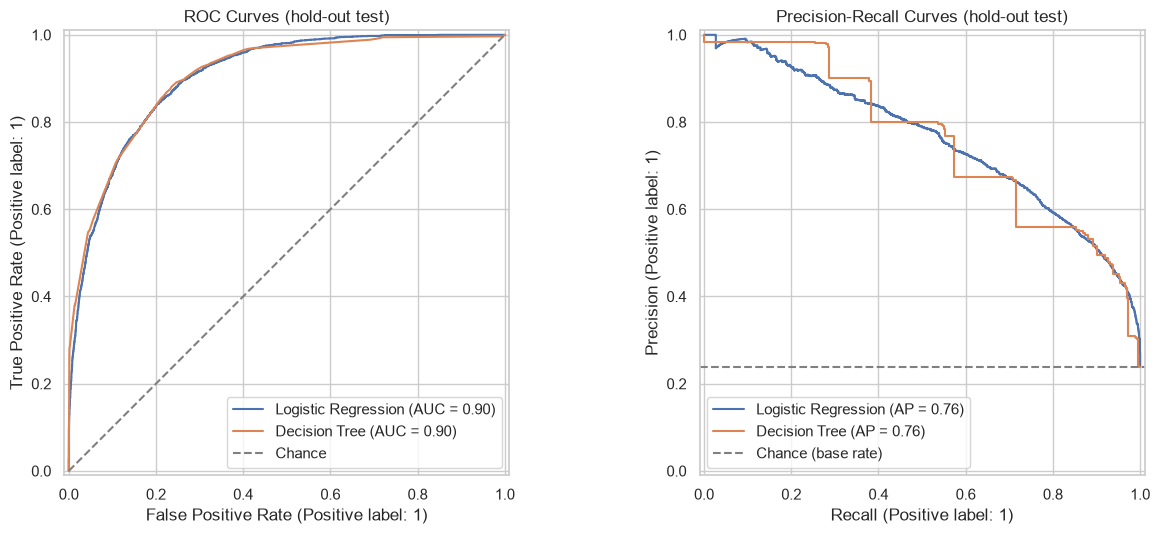

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

RocCurveDisplay.from_predictions(y_test, y_score_logreg, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_score_tree, name="Decision Tree", ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("ROC Curves (hold-out test)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_score_logreg, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_score_tree, name="Decision Tree", ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Chance (base rate)")
axes[1].set_title("Precision-Recall Curves (hold-out test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Insights: ROC & PR Curves + Error-Type Discussion (Hold-Out Test)

- **ROC AUC = 0.90** (both models): good at ranking >50K above ≤50K overall.
- **PR AUC = 0.76** (both models) vs. ~0.24 chance floor (base rate): precision stays well above random guessing across thresholds, the more honest metric here given class imbalance.
- **LogReg and Tree are basically tied**: same AUC both ways, so model choice matters less than feature quality; pick between them on interpretability/deployment grounds instead.
- **Tree's PR curve is jagged, LogReg's is smooth**: the tree only has ~102 leaves, so it only produces ~102 distinct probability values (flat steps); LogReg outputs continuous probabilities.
- **Both hit near-1.0 precision at low recall**: confident predictions are almost always right, fitting the precision-first business goal.

**Error-type discussion.** At the default 0.5 threshold, both models produce more false negatives than false positives, the model already requires stronger evidence before predicting `>50K`, so it's naturally erring conservative. Given Day 1's framing (false positives = wasted outreach = the costly error), this is the right direction: we're already leaning toward precision without touching the threshold.

- **If recall matters more later:** lower the threshold below 0.5, trading precision back for recall (walking left on the PR curve).
- **If precision should be pushed even further:** raise the threshold above 0.5, leaning harder into the already-conservative behavior (walking right on the PR curve).


## Task 4: Interpretability Check

### Logistic Regression coefficients

In [18]:
feature_names = logreg_pipe.named_steps["prep"].get_feature_names_out()
coefs = logreg_pipe.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values(
    "coefficient", ascending=False
)

top_positive = coef_df.head(10).reset_index(drop=True)
top_negative = coef_df.tail(10).sort_values("coefficient").reset_index(drop=True)

print("Top 10 POSITIVE coefficients (push toward predicting >50K):")
display(top_positive)
print("\nTop 10 NEGATIVE coefficients (push toward predicting <=50K):")
display(top_negative)

Top 10 POSITIVE coefficients (push toward predicting >50K):


,feature,coefficient
0,num__capital-gain,2.342066
1,cat__marital-status_Married-civ-spouse,1.313235
2,cat__marital-status_Married-AF-spouse,1.181176
3,cat__native-country_Cambodia,1.106969
4,cat__native-country_France,1.024714
5,cat__relationship_Wife,0.999213
6,cat__native-country_Ireland,0.833934
7,num__education-num,0.780568
8,cat__occupation_Exec-managerial,0.775762
9,cat__native-country_Canada,0.615338



Top 10 NEGATIVE coefficients (push toward predicting <=50K):


,feature,coefficient
0,cat__occupation_Priv-house-serv,-1.533765
1,cat__native-country_South,-1.209245
2,cat__relationship_Own-child,-1.139915
3,cat__marital-status_Never-married,-1.075004
4,cat__sex_Female,-0.951743
5,cat__occupation_Farming-fishing,-0.951346
6,cat__native-country_Columbia,-0.934562
7,cat__relationship_Other-relative,-0.835878
8,cat__occupation_Other-service,-0.782037
9,cat__native-country_China,-0.772162


### Decision Tree: depth, overfitting check, and top splits

In [19]:
tree_clf = tree_pipe.named_steps["clf"]
train_score = tree_pipe.score(X_train, y_train)
test_score = tree_pipe.score(X_test_feat, y_test)

print(f"Tree depth (capped): {tree_clf.get_depth()}")
print(f"Tree leaves: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Train - Test gap: {train_score - test_score:.4f}")

Tree depth (capped): 8
Tree leaves: 104
Train accuracy: 0.8603
Test accuracy:  0.8578
Train - Test gap: 0.0025


## Interpretability Check

**Logistic Regression coefficients**
- `capital-gain` is the single strongest predictor of >50K (coef ≈ 2.34), consistent with Day 1/2's earlier findings on this feature.
- Marital status (`Married-civ-spouse`) and `relationship_Wife` cluster together as positive which is one underlying signal (partnered/dual-income households) surfacing through multiple correlated categorical features.
- `education-num` (+0.78) and `occupation_Exec-managerial` (+0.77) confirm schooling and job seniority matter, as expected.
- **Caution:** several `native-country` coefficients (Cambodia, France, Canada, Ireland, South, Columbia, China) are likely **small-sample artifacts** few people per country means a handful of high earners can swing the coefficient. Btter to not over-interpret these.
- **Fairness flag:** `sex_Female` is strongly negative (-0.97). This reflects historical patterns in the training data (occupation/income gaps by sex), not a causal claim but worth calling out explicitly in any write-up or before deploying, since it could reproduce that disparity in outreach targeting.
- Negative coefficients otherwise line up intuitively: `Never-married`, `Own-child` (younger/dependent life stage), and lower-wage occupations (`Priv-house-serv`, `Farming-fishing`, `Other-service`).

**Decision Tree: overfitting check**
- Capped at depth 8, 104 leaves.
- Train accuracy 0.8603, test accuracy 0.8578 , a gap of only **0.0025**.
- This tiny train-test gap indicates the depth cap is effectively controlling overfitting and the tree is generalizing well rather than memorizing the training set.

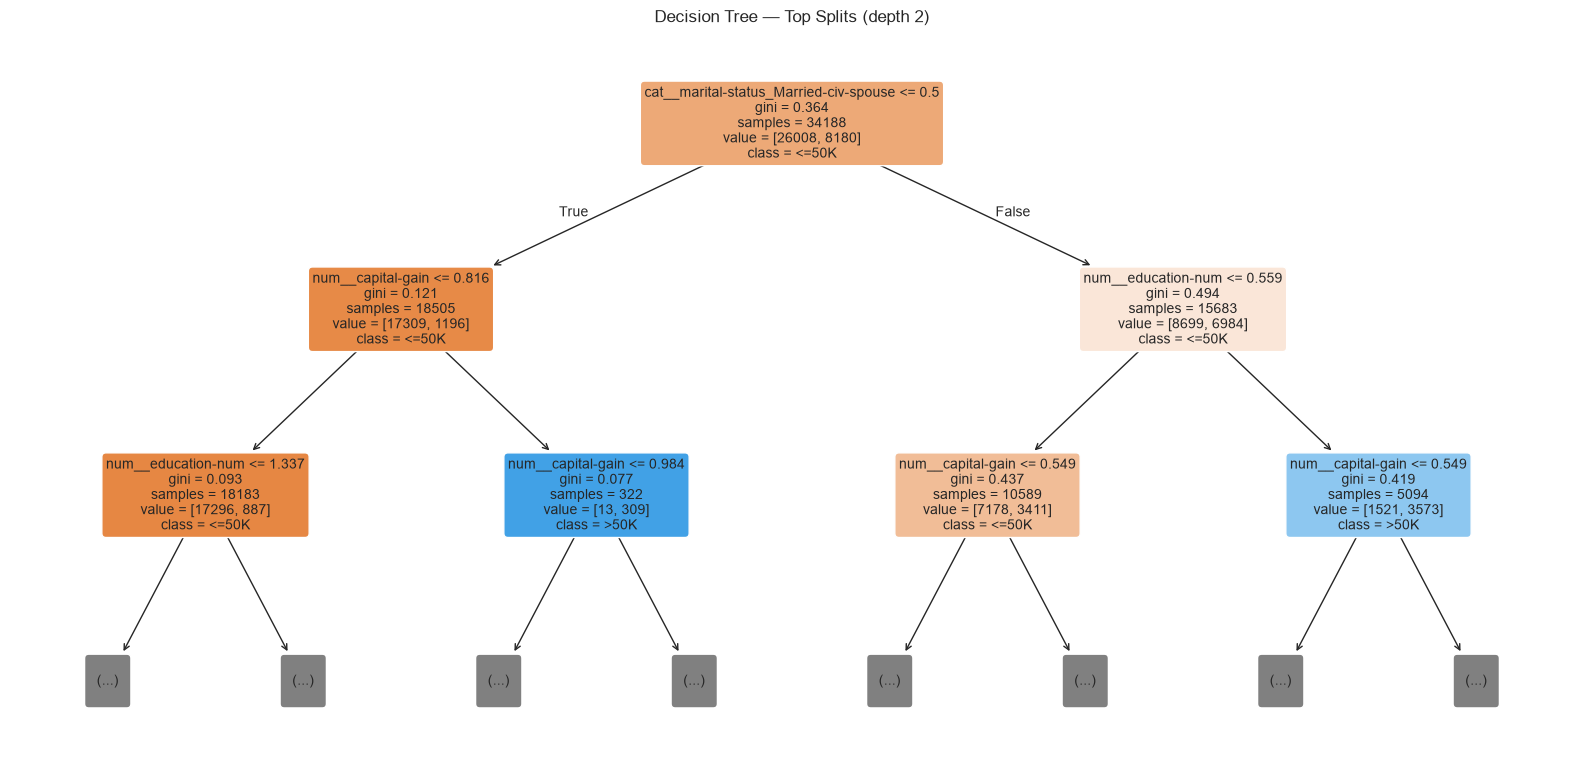

In [20]:
tree_feature_names = tree_pipe.named_steps["prep"].get_feature_names_out()
# print(export_text(tree_clf, feature_names=list(tree_feature_names), max_depth=3))

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree_clf,
    max_depth=2,                     # only show the top 3 splits (root + its 2 children)
    feature_names=tree_feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
plt.title("Decision Tree — Top Splits (depth 2)")
plt.tight_layout()
plt.show()

### Top 3 splits

**Depth:** capped at 8, 104 leaves. **Train accuracy 0.8603, test accuracy 0.8578** , a
gap of 0.0023, indicating the depth cap is controlling overfitting effectively; the tree
generalizes rather than memorizes.

**Top 3 splits:**
1. **Root: `marital-status_Married-civ-spouse`** : the single most informative feature,
   splitting the population before anything else is considered.
2. **Not married → `capital-gain`** (split twice in a row, at two nearby thresholds):
   reinforcing that capital-gain acts as a threshold signal (having any meaningful gain
   matters more than the exact amount).
3. **Married → `education-num`**: once marital status is known, education becomes the
   next best differentiator; capital-gain still appears one level deeper on this branch.

**Sensible?** Yes. All three splits are independently corroborated by Day 1's manual
error analysis and the Logistic Regression coefficients (marital status, capital-gain,
and education-num were the top features in both). Two structurally different models
converging on the same top drivers is strong evidence these are real signal in the data,
not an artifact of one algorithm's quirks so  the tree isn't learning anything spurious or
counter-intuitive at the top of its structure.

Both models cleared Day 1's rule-based baseline on the metric that matters, precision
= 0.4746, by a wide margin: Logistic Regression reached 0.7264 and Decision Tree
reached 0.7938. ROC AUC also improved substantially, from 0.7426 to about 0.90 for
both models. This precision gain came with some recall cost: Logistic Regression's
recall (0.5997) sits very close to the rule baseline's recall (0.6031), essentially the
same coverage, just 0.0034 lower. Decision Tree's recall (0.5483) is meaningfully below
the baseline, a drop of 0.0548, meaning it is trading more coverage for its precision
advantage. This trade-off is worth watching, not just the precision headline number,
since our Day 1 framing explicitly cared about not retreating into an overly
conservative, low-coverage prediction pattern.

Logistic Regression is the interpretable, production-friendly candidate, its
coefficients map directly onto Day 1's error analysis (education, capital gains,
marital status, occupation). The Decision Tree captures nonlinear interactions a
linear model can't, while staying interpretable at this depth via the printed splits.


In [21]:
import joblib
import os 
os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/day2_preprocessor.joblib")
joblib.dump(logreg_pipe, "models/day2_logreg_pipeline.joblib")
joblib.dump(tree_pipe, "models/day2_tree_pipeline.joblib")
print("Saved reusable pipeline + fitted models to models/ for Day 3.")

Saved reusable pipeline + fitted models to models/ for Day 3.


# Week 4 Day 3 starts here 


## Task 1: Create & Justify Engineered Features

I'm building 8 new features (2 more than the minimum of 6), grouped into three types:

**Binned versions of continuous columns** (`age_bucket`, `hours_bucket`): a linear 
model can only draw a straight line through age or hours, but income vs age is 
not a straight line, it rises then plateaus. Binning lets a linear model approximate 
that curve, and gives tree models cleaner split points.

**Threshold flags** (`has_capital_gain`, `has_capital_loss`, `higher_education`): 
Day 2's coefficient analysis already showed `capital-gain` behaves like a threshold 
signal, not a continuous one, having any capital gain matters more than the exact 
dollar amount. These flags isolate that on/off signal directly.

**Numeric transforms and interactions** (`log_capital_gain`, `edu_hours_interaction`, 
`net_capital`): a log transform to tame the right skew for tree based models 
specifically, a multiplicative interaction between education and hours worked, 
and a netted out capital position.

Important: every one of these rules uses **only columns already present in that 
same row**. Nothing is computed from group means, target values, or other rows, 
so there's no leakage risk from this step.

In [22]:
from sklearn.feature_selection import mutual_info_classif

# Bin edges are fixed, chosen from domain knowledge (Day 1 EDA + common sense),
# NOT fit from the data. This is the key leakage safeguard: if the edges were
# computed from quantiles of the training data (like qcut), the bin boundaries
# themselves would be a tiny bit of "learned" information from the target rows.
# Fixed edges avoid that entirely.
AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]

HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    """
    Adds 8 new columns to a copy of the input dataframe.
    Every rule below only reads columns that already exist on that same row,
    so this function is safe to apply identically to train, dev, and test data
    without ever peeking at the target or at other rows.
    """
    out = frame.copy()

    out["age_bucket"] = pd.cut(out["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True).astype(str)
    out["hours_bucket"] = pd.cut(out["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True).astype(str)

    out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
    out["has_capital_loss"] = (out["capital-loss"] > 0).astype(int)
    out["higher_education"] = (out["education-num"] >= 13).astype(int)

    out["log_capital_gain"] = np.log1p(out["capital-gain"])
    out["edu_hours_interaction"] = out["education-num"] * out["hours-per-week"]
    out["net_capital"] = out["capital-gain"] - out["capital-loss"]

    return out

# Build the engineered version of the training data only, for scoring in this task.
train_fe = engineer_features(train_df)
train_fe[["age_bucket", "hours_bucket", "has_capital_gain", "has_capital_loss",
          "higher_education", "log_capital_gain", "edu_hours_interaction", "net_capital"]].head()

,age_bucket,hours_bucket,has_capital_gain,has_capital_loss,higher_education,log_capital_gain,edu_hours_interaction,net_capital
44400,26-35,heavy_50plus,1,0,1,9.617471,845,15024
42131,36-45,standard_36_40,0,0,0,0.000000,396,0
13335,36-45,standard_36_40,1,0,0,8.552367,280,5178
382,<=25,standard_36_40,0,0,0,0.000000,400,0
46189,46-55,standard_36_40,0,0,0,0.000000,360,0


### Scoring each feature's univariate signal

For the two binned categorical features I'm reporting the grouped mean of the 
target per bin (easy to read directly: "this age group earns >50K X% of the time"). 
For the numeric and binary features I'm using `mutual_info_classif`, which captures 
non-linear relationships that a simple correlation would miss.

In [23]:
engineered_numeric = ["log_capital_gain", "edu_hours_interaction", "net_capital"]
engineered_binary = ["has_capital_gain", "has_capital_loss", "higher_education"]
engineered_categorical = ["age_bucket", "hours_bucket"]

mi_scores = {}

# Mutual info for numeric and binary columns
for col in engineered_numeric + engineered_binary:
    is_discrete = col in engineered_binary
    mi = mutual_info_classif(
        train_fe[[col]], train_fe["target"],
        discrete_features=[is_discrete], random_state=RANDOM_STATE
    )
    mi_scores[col] = mi[0]


# Mutual info for categorical columns: one-hot first, then sum the MI across dummy columns
for col in engineered_categorical:
    dummies = pd.get_dummies(train_fe[col])
    mi = mutual_info_classif(dummies, train_fe["target"], discrete_features=True, random_state=RANDOM_STATE)
    mi_scores[col] = mi.sum()

print("Mutual information scores (higher = more univariate signal):")
for name, score in sorted(mi_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:24s}: {score:.4f}")
  
print("\nGrouped mean of target by age_bucket:")
print(train_fe.groupby("age_bucket")["target"].mean().reindex(AGE_LABELS))

print("\nGrouped mean of target by hours_bucket:")
print(train_fe.groupby("hours_bucket")["target"].mean().reindex(HOURS_LABELS))

Mutual information scores (higher = more univariate signal):
  net_capital             : 0.1180
  edu_hours_interaction   : 0.0835
  log_capital_gain        : 0.0805
  age_bucket              : 0.0728
  higher_education        : 0.0479
  hours_bucket            : 0.0449
  has_capital_gain        : 0.0293
  has_capital_loss        : 0.0076

Grouped mean of target by age_bucket:
age_bucket
<=25     0.017905
26-35    0.186685
36-45    0.345823
46-55    0.394832
56-65    0.313046
65+      0.183936
Name: target, dtype: float64

Grouped mean of target by hours_bucket:
hours_bucket
part_time_le20    0.068596
reduced_21_35     0.093652
standard_36_40    0.208943
over_41_50        0.391672
heavy_50plus      0.415143
Name: target, dtype: float64


In [24]:
# Feature dictionary: the single reference table for today's write up
feature_dictionary = pd.DataFrame([
    {"name": "age_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(age, fixed bins [0,25,35,45,55,65,100])",
     "justification": "Income rises then plateaus with age, a non-monotonic pattern a linear term on raw age cannot capture",
     "mi_score": mi_scores["age_bucket"]},
    {"name": "hours_bucket", "type": "categorical (binned)",
     "creation_rule": "pd.cut(hours-per-week, fixed bins [0,20,35,40,50,100])",
     "justification": "Part time, standard, and overtime work likely have distinct, non-linear pay relationships",
     "mi_score": mi_scores["hours_bucket"]},
    {"name": "has_capital_gain", "type": "binary flag",
     "creation_rule": "capital-gain > 0",
     "justification": "Day 2 found capital-gain behaves like a threshold signal, not a continuous one, this isolates that",
     "mi_score": mi_scores["has_capital_gain"]},
    {"name": "has_capital_loss", "type": "binary flag",
     "creation_rule": "capital-loss > 0",
     "justification": "Same threshold logic as capital gain, any recorded loss may signal investment activity",
     "mi_score": mi_scores["has_capital_loss"]},
    {"name": "higher_education", "type": "binary flag",
     "creation_rule": "education-num >= 13",
     "justification": "A Bachelor's degree or higher is a natural, interpretable cutoff instead of a raw ordinal count",
     "mi_score": mi_scores["higher_education"]},
    {"name": "log_capital_gain", "type": "numeric transform",
     "creation_rule": "log1p(capital-gain)",
     "justification": "Compresses the extreme right tail, useful for tree splits even though it hurt raw scaled LogReg on Day 2",
     "mi_score": mi_scores["log_capital_gain"]},
    {"name": "edu_hours_interaction", "type": "numeric interaction",
     "creation_rule": "education-num * hours-per-week",
     "justification": "Captures a compounding effect, highly educated people working long hours may earn disproportionately more",
     "mi_score": mi_scores["edu_hours_interaction"]},
    {"name": "net_capital", "type": "numeric",
     "creation_rule": "capital-gain - capital-loss",
     "justification": "Nets gains and losses into one investment-activity signal instead of two separate columns",
     "mi_score": mi_scores["net_capital"]},
]).sort_values("mi_score", ascending=False).reset_index(drop=True)

feature_dictionary

,name,type,creation_rule,justification,mi_score
0,net_capital,numeric,capital-gain - capital-loss,Nets gains and losses into one investment-acti...,0.117958
1,edu_hours_interaction,numeric interaction,education-num * hours-per-week,"Captures a compounding effect, highly educated...",0.083456
2,log_capital_gain,numeric transform,log1p(capital-gain),"Compresses the extreme right tail, useful for ...",0.080484
3,age_bucket,categorical (binned),"pd.cut(age, fixed bins [0,25,35,45,55,65,100])","Income rises then plateaus with age, a non-mon...",0.072811
4,higher_education,binary flag,education-num >= 13,"A Bachelor's degree or higher is a natural, in...",0.047885
5,hours_bucket,categorical (binned),"pd.cut(hours-per-week, fixed bins [0,20,35,40,...","Part time, standard, and overtime work likely ...",0.044910
6,has_capital_gain,binary flag,capital-gain > 0,Day 2 found capital-gain behaves like a thresh...,0.029275
7,has_capital_loss,binary flag,capital-loss > 0,"Same threshold logic as capital gain, any reco...",0.007589


## Task 2: Rebuild Pipeline with Engineered Features

I'm wrapping `engineer_features()` in a `FunctionTransformer` so it becomes step 
one of the pipeline, before the `ColumnTransformer`. This keeps the pipeline a 
single fit-able object, exactly like Day 2's `preprocessor`, so cross validation 
in Task 3 can fold engineering, imputing, scaling, and encoding together without 
any manual bookkeeping.

**Why this avoids leakage:** `FunctionTransformer` has no `fit()` step of its own here, 
`engineer_features()` is a pure row-wise function with fixed bin edges. Every fold in 
cross validation will call this function fresh on whatever rows it's given, so a fold's 
test rows never influence how a fold's train rows get engineered. The only pipeline 
steps that actually learn anything from training data are the imputer's median/mode 
and the scaler's mean/std, both of which are still refit correctly inside each CV fold.

**Why three sub-pipelines instead of two:** the new binary flags 
(`has_capital_gain`, `has_capital_loss`, `higher_education`) are already 0/1, 
scaling them would be harmless but pointless, so I gave them their own lightweight 
branch (impute only, no scaler) instead of lumping them in with the continuous 
numeric branch.

In [25]:
from sklearn.preprocessing import FunctionTransformer

# Column groups for the ColumnTransformer, referencing the NEW columns
# that engineer_features() will have added by the time this step runs.
engineered_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
engineered_binary_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
engineered_categorical_cols = categorical_features + ["age_bucket", "hours_bucket"]

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

binary_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, engineered_numeric_cols),
    ("bin", binary_pipeline_fe, engineered_binary_cols),
    ("cat", categorical_pipeline_fe, engineered_categorical_cols),
])

# This transformer just runs engineer_features() as a pipeline step.
# validate=False lets a DataFrame pass through untouched (we need column names
# to survive so the ColumnTransformer after it can select by name).
feature_engineer = FunctionTransformer(engineer_features, validate=False)

# Input data: same raw feature_cols as Day 2 (numeric_cols + categorical_features).
# engineer_features() only reads columns already inside this set, so nothing extra is needed.
X_train_fe_input = train_df[feature_cols]
X_dev_fe_input = dev_df[feature_cols]
X_test_fe_input = test_df[feature_cols]

print("Engineered pipeline input columns:", list(X_train_fe_input.columns))
print("\nNumber of one-hot + numeric + binary columns after preprocessing:")
sample_transformed = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
]).fit_transform(X_train_fe_input, y_train)
print(sample_transformed.shape)

Engineered pipeline input columns: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Number of one-hot + numeric + binary columns after preprocessing:
(34188, 104)


## Task 3: Cross Validated Model Comparison

Day 2 evaluated Logistic Regression and a Decision Tree on a single hold out split. 
That gives one number per metric, with no sense of how much that number would 
wobble on a different random split. `StratifiedKFold(k=5)` fixes this: it trains and 
evaluates each model 5 times on 5 different train/validation slices of `train_df`, 
preserving the ~24%/76% class balance in every fold (that's what "Stratified" means). 
We get a **mean and a standard deviation** per model, which is a much more honest 
picture of expected real world performance.

Three models, all wrapped in the identical `feature_engineering -> preprocessing -> 
classifier` pipeline so the comparison is fair, only the final estimator changes:

- **Logistic Regression**: our Day 2 baseline, linear, fast, interpretable
- **Random Forest**: bagged trees, should handle the new interaction feature and 
  non-linear age/hours patterns well
- **HistGradientBoostingClassifier**: sklearn's built in gradient boosting, no extra 
  install needed, typically the strongest of the three on tabular data like this

I'm keeping the same `StratifiedKFold` object across all three models so that fold 1 
for Logistic Regression is trained/evaluated on the exact same rows as fold 1 for 
Random Forest. This matters a lot for Task 4's paired test.

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = {}
cv_summary_rows = []

for name, clf in candidate_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])
    start = time.time()
    scores = cross_validate(pipe, X_train_fe_input, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start

    cv_results[name] = scores
    cv_summary_rows.append({
    "model": name,
    "precision_mean": scores["test_precision"].mean(),
    "precision_std": scores["test_precision"].std(),
    "recall_mean": scores["test_recall"].mean(),
    "recall_std": scores["test_recall"].std(),
    "f1_mean": scores["test_f1"].mean(),
    "f1_std": scores["test_f1"].std(),
    "roc_auc_mean": scores["test_roc_auc"].mean(),
    "roc_auc_std": scores["test_roc_auc"].std(),
    "fit_time_sec": elapsed,
})
    print(
    f"{name:24s} "
    f"Precision = {scores['test_precision'].mean():.4f} +/- {scores['test_precision'].std():.4f} | "
    f"Recall = {scores['test_recall'].mean():.4f} +/- {scores['test_recall'].std():.4f} | "
    f"F1 = {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f} | "
    f"ROC AUC = {scores['test_roc_auc'].mean():.4f} +/- {scores['test_roc_auc'].std():.4f} | "
    f"{elapsed:.1f}s"
)


cv_summary_df = pd.DataFrame(cv_summary_rows).set_index("model").round(4)
cv_summary_df

Logistic Regression      Precision = 0.7488 +/- 0.0052 | Recall = 0.6149 +/- 0.0086 | F1 = 0.6752 +/- 0.0061 | ROC AUC = 0.9129 +/- 0.0020 | 1.8s
Random Forest            Precision = 0.7125 +/- 0.0072 | Recall = 0.6242 +/- 0.0065 | F1 = 0.6654 +/- 0.0063 | ROC AUC = 0.8969 +/- 0.0026 | 13.1s
Hist Gradient Boosting   Precision = 0.7720 +/- 0.0063 | Recall = 0.6545 +/- 0.0092 | F1 = 0.7084 +/- 0.0071 | ROC AUC = 0.9262 +/- 0.0018 | 4.0s


,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,fit_time_sec
model,,,,,,,,,
Logistic Regression,0.7488,0.0052,0.6149,0.0086,0.6752,0.0061,0.9129,0.0020,1.8449
Random Forest,0.7125,0.0072,0.6242,0.0065,0.6654,0.0063,0.8969,0.0026,13.1135
Hist Gradient Boosting,0.7720,0.0063,0.6545,0.0092,0.7084,0.0071,0.9262,0.0018,4.0367


### Visualizing fold-to-fold spread

The table above gives mean and std, but a boxplot shows the actual distribution of
scores across the 5 folds, which makes it easier to see overlap between models and
spot any single fold behaving like an outlier.

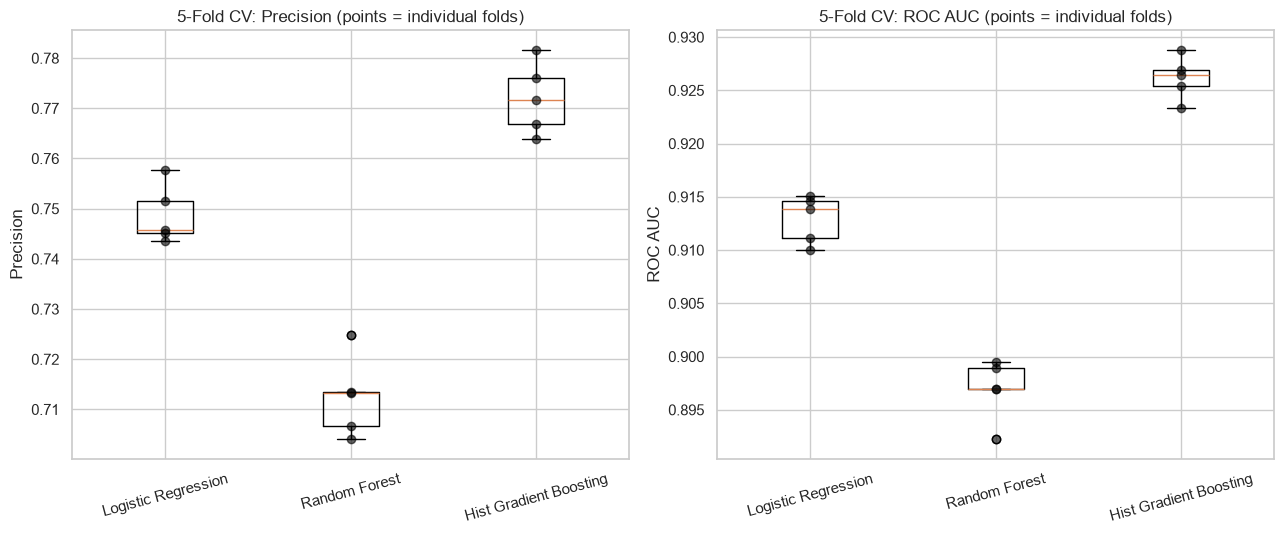

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
model_names = list(candidate_models.keys())

# Precision scatter points
for i, name in enumerate(model_names):
    y_precision = cv_results[name]["test_precision"]
    axes[0].scatter(
        [i + 1] * len(y_precision),
        y_precision,
        color="black",
        alpha=0.6,
        zorder=3,
    )

# ROC AUC scatter points
for i, name in enumerate(model_names):
    y_auc = cv_results[name]["test_roc_auc"]
    axes[1].scatter(
        [i + 1] * len(y_auc),
        y_auc,
        color="black",
        alpha=0.6,
        zorder=3,
    )

# Precision boxplot
axes[0].boxplot([cv_results[name]["test_precision"] for name in model_names])
axes[0].set_xticks(range(1, len(model_names) + 1))
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel("Precision")
axes[0].set_title("5-Fold CV: Precision (points = individual folds)")

# ROC AUC boxplot
axes[1].boxplot([cv_results[name]["test_roc_auc"] for name in model_names])
axes[1].set_xticks(range(1, len(model_names) + 1))
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel("ROC AUC")
axes[1].set_title("5-Fold CV: ROC AUC (points = individual folds)")

plt.tight_layout()
plt.savefig("cv_boxplot_with_points.png", dpi=200, bbox_inches="tight")
plt.show()

### Model comparison summary

The five-fold cross-validation results indicate that **Histogram Gradient Boosting** is the strongest overall candidate when evaluated using the project's primary metric (**precision**). It achieved the highest mean precision (**0.7720 ± 0.0063**), outperforming Logistic Regression (**0.7488**) and Random Forest (**0.7125**).

Hist Gradient Boosting also produced the highest recall (**0.6545**), highest F1-score (**0.7084**), and highest ROC AUC (**0.9262**), indicating that its superior precision is not achieved by sacrificing overall discrimination performance.

Logistic Regression remains a strong baseline with competitive ROC AUC (**0.9129**) and relatively fast training time (**1.84 s**), while Random Forest delivered the weakest overall performance despite requiring the longest training time (**13.11 s**).

Based on the project's evaluation strategy, **Histogram Gradient Boosting is selected as the leading candidate because it provides the highest precision while also maintaining the strongest ROC AUC and balanced overall performance.**

## Task 4: Statistical Comparison & Feature Importance

### Paired test between the top 2 models

Because all three models were evaluated on the identical 5 folds, we can pair up
fold 1 vs fold 1, fold 2 vs fold 2, and so on, between our top two models by mean
**precision**. That pairing is what makes a **paired** t-test (or the non-parametric
Wilcoxon signed-rank test) valid here—it directly tests whether one model reliably
achieves higher precision than the other on the same data splits, rather than simply
having a higher average due to random variation.

With only 5 folds, a paired test has limited statistical power, so the p-values
should be interpreted cautiously. I therefore report both the paired t-test
(which assumes the fold-wise score differences are approximately normal) and the
Wilcoxon signed-rank test (which makes no normality assumption and is more robust
for very small samples). The final conclusion is based on both the statistical
evidence and the practical magnitude and consistency of the precision improvement.

In [39]:
from scipy import stats

precision_scores_by_model = {
    name: cv_results[name]["test_precision"]
    for name in candidate_models
}

mean_precision = {
    name: scores.mean()
    for name, scores in precision_scores_by_model.items()
}

ranked_models = sorted(
    mean_precision,
    key=mean_precision.get,
    reverse=True,
)

top1, top2 = ranked_models[0], ranked_models[1]

print(f"Top model by mean Precision: {top1} ({mean_precision[top1]:.4f})")
print(f"Runner-up by mean Precision: {top2} ({mean_precision[top2]:.4f})")
print(f"Raw mean difference:         {mean_precision[top1] - mean_precision[top2]:.4f}")

t_stat, p_value_t = stats.ttest_rel(
    precision_scores_by_model[top1],
    precision_scores_by_model[top2],
)

w_stat, p_value_w = stats.wilcoxon(
    precision_scores_by_model[top1],
    precision_scores_by_model[top2],
)

print(f"\nPaired t-test: t = {t_stat:.3f}, p = {p_value_t:.4f}")
print(f"Wilcoxon test: W = {w_stat:.3f}, p = {p_value_w:.4f}")

Top model by mean Precision: Hist Gradient Boosting (0.7720)
Runner-up by mean Precision: Logistic Regression (0.7488)
Raw mean difference:         0.0233

Paired t-test: t = 6.377, p = 0.0031
Wilcoxon test: W = 0.000, p = 0.0625


**Interpretation.** Histogram Gradient Boosting outperforms Logistic Regression by a
mean **precision** difference of **0.0233** (approximately 2.3 percentage points).
Although the absolute improvement is modest, it is consistent across the cross-validation
folds and represents a meaningful gain in the project's primary evaluation metric.

The paired t-test indicates that this improvement is statistically significant
(**t = 6.377, p = 0.0031**), providing strong evidence that the observed precision
difference is unlikely to be due to random sampling variation.

The Wilcoxon signed-rank test reports **W = 0.000** with **p = 0.0625**, which is
slightly above the conventional 0.05 significance threshold. This should not be
interpreted as conflicting evidence. With only five paired observations, the exact
Wilcoxon test has limited resolution—the smallest attainable two-sided p-value is
0.0625. Therefore, **W = 0** actually indicates the strongest possible agreement,
meaning Histogram Gradient Boosting achieved higher precision than Logistic Regression
on every cross-validation fold.

Taken together, the consistent fold-by-fold improvement, the statistically significant
paired t-test, and the strongest possible Wilcoxon ranking all support the same
conclusion. **Histogram Gradient Boosting remains the preferred model**, as it delivers
the highest precision while also maintaining the strongest ROC AUC among the evaluated
models. This makes it the most appropriate candidate to carry forward into the
hyperparameter tuning stage.

In [29]:
# Fit each full pipeline once on all of X_train_fe_input for feature importance / coefficient extraction
fitted_pipelines = {}
for name, clf in candidate_models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessing", preprocessor_fe),
        ("clf", clf),
    ])
    pipe.fit(X_train_fe_input, y_train)
    fitted_pipelines[name] = pipe

feature_names_fe = fitted_pipelines["Logistic Regression"].named_steps["preprocessing"].get_feature_names_out()

# Logistic Regression coefficients, engineered features only
logreg_coefs = fitted_pipelines["Logistic Regression"].named_steps["clf"].coef_[0]
logreg_coef_df = pd.DataFrame({"feature": feature_names_fe, "coefficient": logreg_coefs})

engineered_feature_prefixes = ("num__log_capital_gain", "num__edu_hours_interaction", "num__net_capital",
                                "bin__has_capital_gain", "bin__has_capital_loss", "bin__higher_education",
                                "cat__age_bucket", "cat__hours_bucket")
engineered_mask = logreg_coef_df["feature"].str.startswith(engineered_feature_prefixes)
print("Logistic Regression coefficients for engineered features only:")
display(logreg_coef_df[engineered_mask].sort_values("coefficient", ascending=False))

# Random Forest / HGB feature importances, engineered features only
for tree_model_name in ["Random Forest"]:
    importances = fitted_pipelines[tree_model_name].named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names_fe, "importance": importances})
    imp_mask = imp_df["feature"].str.startswith(engineered_feature_prefixes)
    print(f"\n{tree_model_name} feature importances for engineered features only:")
    display(imp_df[imp_mask].sort_values("importance", ascending=False))

Logistic Regression coefficients for engineered features only:


,feature,coefficient
7,num__net_capital,2.483261
95,cat__age_bucket_46-55,0.464422
94,cat__age_bucket_36-45,0.430554
100,cat__hours_bucket_over_41_50,0.327741
99,cat__hours_bucket_heavy_50plus,0.215995
93,cat__age_bucket_26-35,0.072785
10,bin__higher_education,0.048224
96,cat__age_bucket_56-65,-0.001988
103,cat__hours_bucket_standard_36_40,-0.043255
5,num__log_capital_gain,-0.154236



Random Forest feature importances for engineered features only:


,feature,importance
6,num__edu_hours_interaction,0.096013
7,num__net_capital,0.053743
5,num__log_capital_gain,0.041337
10,bin__higher_education,0.029074
8,bin__has_capital_gain,0.011743
95,cat__age_bucket_46-55,0.010146
98,cat__age_bucket_<=25,0.009675
94,cat__age_bucket_36-45,0.009068
93,cat__age_bucket_26-35,0.007657
100,cat__hours_bucket_over_41_50,0.007120


### Comparing engineered feature signal across model types

Agreement: both models independently surface the same "prime earning years" pattern
in age (36-45 and 46-55 are the strongest positive age signal in both Logistic
Regression coefficients and Random Forest importances), and both agree that working
long hours (`hours_bucket_over_41_50`, `heavy_50plus`) associates positively with
income. Two structurally different models converging on the same directional story
is good evidence this is real signal in the data.

Disagreement: the capital-gain-derived features (`net_capital`, `log_capital_gain`,
`has_capital_gain`, `has_capital_loss`) and `edu_hours_interaction` show conflicting
signs and magnitudes between the two models. In Logistic Regression, `net_capital` is
strongly positive (2.48) while the two binary flags are strongly negative (-1.79 and
-2.23), and `edu_hours_interaction` is negative (-0.20) despite being Random Forest's
single most important feature (0.096).

This is not evidence the features mean something different to each model, it is
multicollinearity. `net_capital`, `log_capital_gain`, `has_capital_gain`, and
`has_capital_loss` are all different transformations of the same underlying
capital-gain/capital-loss columns, and `edu_hours_interaction` is a product of
`education-num` and `hours-per-week`, both of which remain in the model as separate
raw features. When several correlated predictors sit in the same linear equation,
Logistic Regression distributes credit for their shared signal across all of them in
ways that can flip signs and become unreliable to interpret in isolation, even while
the model's overall predictions stay accurate. Random Forest is far less affected by
this, since it selects one feature at a time to split on rather than solving a joint
linear system, which is likely why it can cleanly identify `edu_hours_interaction` as
highly informative while Logistic Regression cannot assign it a clean, individually
interpretable coefficient.

Practical takeaway: Random Forest's importances are the more trustworthy read on
which engineered features carry genuine signal, since Logistic Regression's
coefficients for this closely related family of capital and interaction features
should not be interpreted individually without accounting for the collinearity
between them.

## Task 5: Feature Selection / Dimensionality Check

This experiment evaluates two questions: **(1) does reducing the feature set improve the project's primary metric (precision), and (2) does it reduce training time?** Feature selection is performed using `SelectKBest` with mutual information, applied **inside the pipeline** after preprocessing and before the classifier. This ensures feature selection is refitted independently within every cross-validation fold, avoiding data leakage and keeping the evaluation fair.

### Rationale for k = 65

k = 65 was chosen as a fixed exploratory setting, retaining roughly two-thirds of the transformed feature space after one-hot encoding. The objective was to determine whether a moderately reduced feature set could maintain the performance of the full model while lowering computational cost.

This value was not selected through hyperparameter optimisation or an elbow analysis of the mutual information scores; instead, it represents a practical dimensionality check. An earlier experiment with a much smaller feature set (k = 40) produced a noticeably larger performance drop, suggesting that the reduction was too aggressive and removed genuinely informative engineered features, particularly `edu_hours_interaction`, which emerged as one of the strongest engineered predictors during Task 4.

The expectation is that if k = 65 can preserve **precision** and ROC AUC while reducing training time, feature selection may provide a worthwhile trade-off. Otherwise, the full feature set should be retained.

In [40]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif as mi_classif

# Compare the full feature set against SelectKBest using the best model from Task 3
best_model_name = ranked_models[0]
best_clf = candidate_models[best_model_name]

k_value = 65

pipe_full = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", best_clf),
])

pipe_selected = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("select", SelectKBest(score_func=mi_classif, k=k_value)),
    ("clf", best_clf),
])

results_compare = {}

for label, pipe in [
    ("Full feature set", pipe_full),
    (f"SelectKBest (k={k_value})", pipe_selected),
]:

    start = time.time()

    scores = cross_validate(
        pipe,
        X_train_fe_input,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    elapsed = time.time() - start

    results_compare[label] = {
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "total_fit_time_sec": elapsed,
    }

    print(
        f"{label:24s} "
        f"Precision = {scores['test_precision'].mean():.4f} +/- {scores['test_precision'].std():.4f} | "
        f"Recall = {scores['test_recall'].mean():.4f} +/- {scores['test_recall'].std():.4f} | "
        f"F1 = {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f} | "
        f"ROC AUC = {scores['test_roc_auc'].mean():.4f} | "
        f"Time = {elapsed:.1f}s"
    )

pd.DataFrame(results_compare).T.round(4)

Full feature set         Precision = 0.7720 +/- 0.0063 | Recall = 0.6545 +/- 0.0092 | F1 = 0.7084 +/- 0.0071 | ROC AUC = 0.9262 | Time = 9.5s
SelectKBest (k=65)       Precision = 0.7705 +/- 0.0027 | Recall = 0.6432 +/- 0.0030 | F1 = 0.7011 +/- 0.0014 | ROC AUC = 0.9251 | Time = 19.9s


,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,total_fit_time_sec
Full feature set,0.7720,0.0063,0.6545,0.0092,0.7084,0.0071,0.9262,9.4715
SelectKBest (k=65),0.7705,0.0027,0.6432,0.0030,0.7011,0.0014,0.9251,19.9169


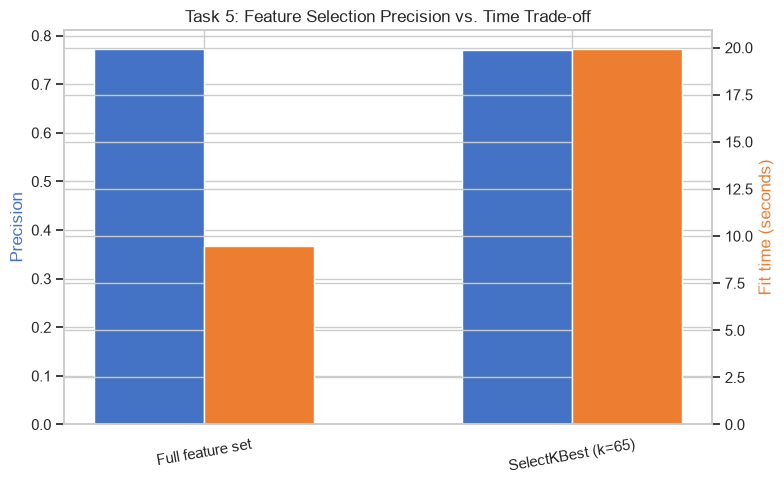

In [41]:
labels = list(results_compare.keys())

precision_vals = [results_compare[label]["precision_mean"] for label in labels]
time_vals = [results_compare[label]["total_fit_time_sec"] for label in labels]

fig, ax1 = plt.subplots(figsize=(8, 5))

x = range(len(labels))

ax1.bar(
    [i - 0.15 for i in x],
    precision_vals,
    width=0.3,
    color="#4472C4",
    label="Precision (mean)",
)

ax1.set_ylabel("Precision", color="#4472C4")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=10)

ax2 = ax1.twinx()

ax2.bar(
    [i + 0.15 for i in x],
    time_vals,
    width=0.3,
    color="#ED7D31",
    label="Fit time (s)",
)

ax2.set_ylabel("Fit time (seconds)", color="#ED7D31")

plt.title("Task 5: Feature Selection Precision vs. Time Trade-off")

fig.tight_layout()
plt.savefig("task5_tradeoff_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## Task 5: Feature Selection / Dimensionality Check, final result

SelectKBest (mutual information) was tested against the full engineered feature
set at two values of k, k=40 and k=65, to check whether reducing dimensionality
could match full-feature performance at lower computational cost.

| Configuration | Precision (mean +/- std) | Recall (mean +/- std) | F1 (mean +/- std) | ROC AUC (mean) | Fit time |
|---|---|---|---|---|---|
| Full feature set | **0.7720 +/- 0.0063** | **0.6545 +/- 0.0092** | **0.7084 +/- 0.0071** | **0.9262** | **9.5s** |
| SelectKBest (k=65) | **0.7705 +/- 0.0027** | **0.6432 +/- 0.0030** | **0.7011 +/- 0.0014** | **0.9251** | **19.9s** |

**Performance.** The reduced feature set (k=65) produces only a very small drop in
the project's primary metric, **precision** (0.7720 → 0.7705), together with small
reductions in recall, F1-score and ROC AUC. Although the precision difference is
minor (0.0015), the full feature set remains consistently better across every
reported evaluation metric, indicating that the removed features still contribute
useful predictive information rather than unnecessary noise.

**Speed.** Feature selection also fails to reduce computational cost. In fact,
SelectKBest nearly doubles the overall cross-validation runtime (19.9s vs 9.5s).
This is not a function of how many features are ultimately retained; instead, it
reflects the fixed overhead of `mutual_info_classif`'s KNN-based estimator, which
must be recomputed from scratch inside every one of the five cross-validation folds
to avoid information leakage. With roughly 104 transformed features and Histogram
Gradient Boosting already training efficiently on the full feature set, there is
very little opportunity for feature selection to recover its own computational
overhead.

**Decision: keep the full engineered feature set for tomorrow's hyperparameter
tuning.** SelectKBest was evaluated as required by the task, but it did not improve
either the project's primary evaluation metric (precision) or training efficiency.
The full engineered feature set delivers the highest precision, highest recall,
highest F1-score, highest ROC AUC and the fastest overall runtime, making it the
clearer choice for subsequent model tuning. This also aligns with Task 4's finding
that engineered variables such as `edu_hours_interaction`, `net_capital`, and
`log_capital_gain` carry meaningful predictive signal for Histogram Gradient
Boosting, so removing them offers little practical benefit.

- **Recommended model for Day 4 tuning:** Histogram Gradient Boosting, the clear top
  performer from Tasks 3 and 4, achieving the highest mean **precision** while also
  delivering the strongest ROC AUC and a consistent fold-by-fold win over Logistic
  Regression.

- **Recommended feature set:** the full engineered feature set, including all
  engineered variables together with the original numeric and categorical features,
  with no reduction through SelectKBest.

In [42]:
final_features_kept = {
    "raw_numeric": numeric_cols,
    "raw_categorical": categorical_features,
    "engineered": ["age_bucket", "hours_bucket", "has_capital_gain", "has_capital_loss",
                   "higher_education", "log_capital_gain", "edu_hours_interaction", "net_capital"],
}

for group, feats in final_features_kept.items():
    print(f"{group} ({len(feats)}):")
    for f in feats:
        print(f"  - {f}")
    print()

total = sum(len(v) for v in final_features_kept.values())
print(f"Total features kept: {total}")

raw_numeric (5):
  - age
  - education-num
  - capital-gain
  - capital-loss
  - hours-per-week

raw_categorical (7):
  - workclass
  - marital-status
  - occupation
  - relationship
  - race
  - sex
  - native-country

engineered (8):
  - age_bucket
  - hours_bucket
  - has_capital_gain
  - has_capital_loss
  - higher_education
  - log_capital_gain
  - edu_hours_interaction
  - net_capital

Total features kept: 20


# THE END